In [9]:
"""
Alpha Vantage Trading Data Visualization
Stocks, Crypto, and Macroeconomic Indicators
"""

import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from pathlib import Path
from os import getenv
import numpy as np

In [10]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Replace with your API key from https://www.alphavantage.co/support/#api-key
API_KEY = getenv('ALPHA_VANTAGE_API_KEY')
BASE_URL = 'https://www.alphavantage.co/query'

# Output directory for saved plots (relative to notebook location)
OUTPUT_DIR = Path(__file__).parent / 'outputs' if '__file__' in dir() else Path.cwd() / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

Alpha Vantage Trading Data Analysis

📊 Fetching Stock Data...
  - Fetching AAPL...
    ✓ Got 100 days of data
  - Fetching MSFT...
Error fetching MSFT: {'Information': 'Thank you for using Alpha Vantage! Please consider spreading out your free API requests more sparingly (1 request per second). You may subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to lift the free key rate limit (25 requests per day), raise the per-second burst limit, and instantly unlock all premium endpoints'}
  - Fetching GOOGL...
    ✓ Got 100 days of data

✓ Saved: c:\Users\Maverick\Documents\GitHub\reinforcement\notebooks\outputs\1_stock_comparison.png
✓ Saved: c:\Users\Maverick\Documents\GitHub\reinforcement\notebooks\outputs\2_stock_detail.png

📈 Fetching Technical Indicators...
  - RSI for AAPL...
  - SMA for AAPL...
✓ Saved: c:\Users\Maverick\Documents\GitHub\reinforcement\notebooks\outputs\3_technical_indicators.png

₿ Fetching Cryptocurrency Data...
  - Fetching BTC...
    ✓ 

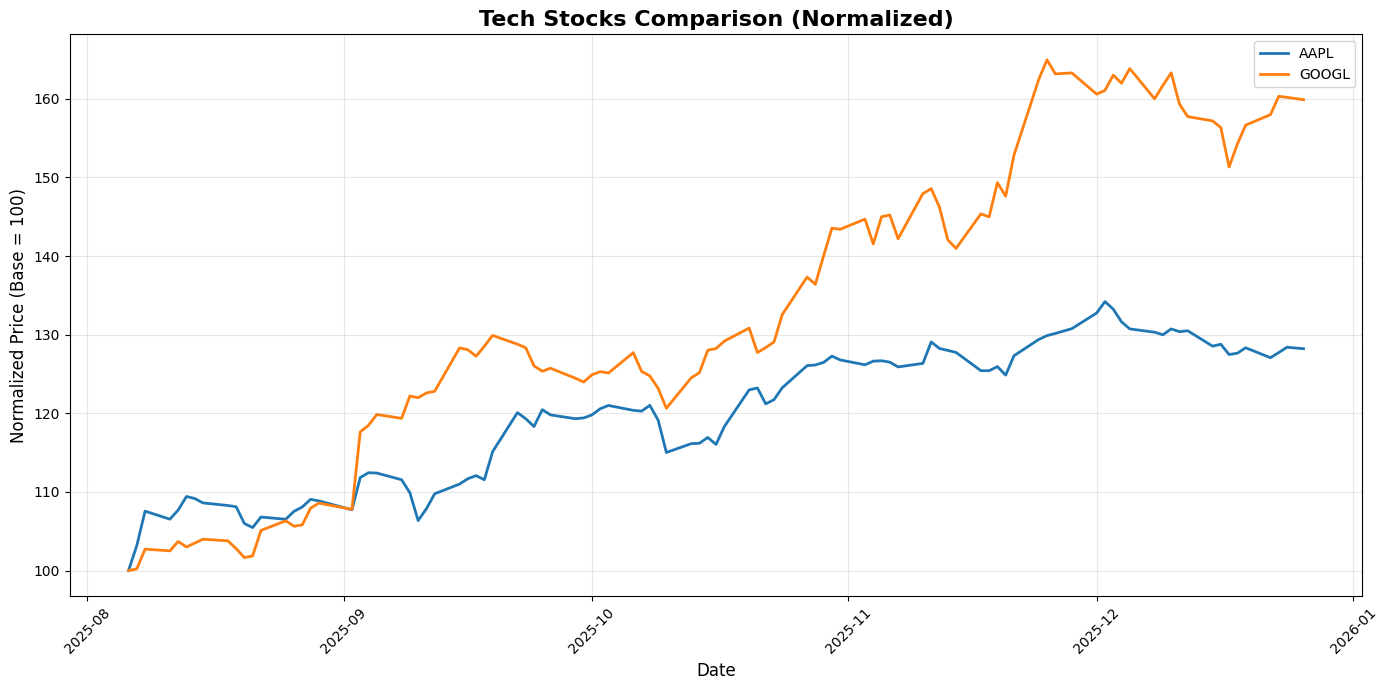

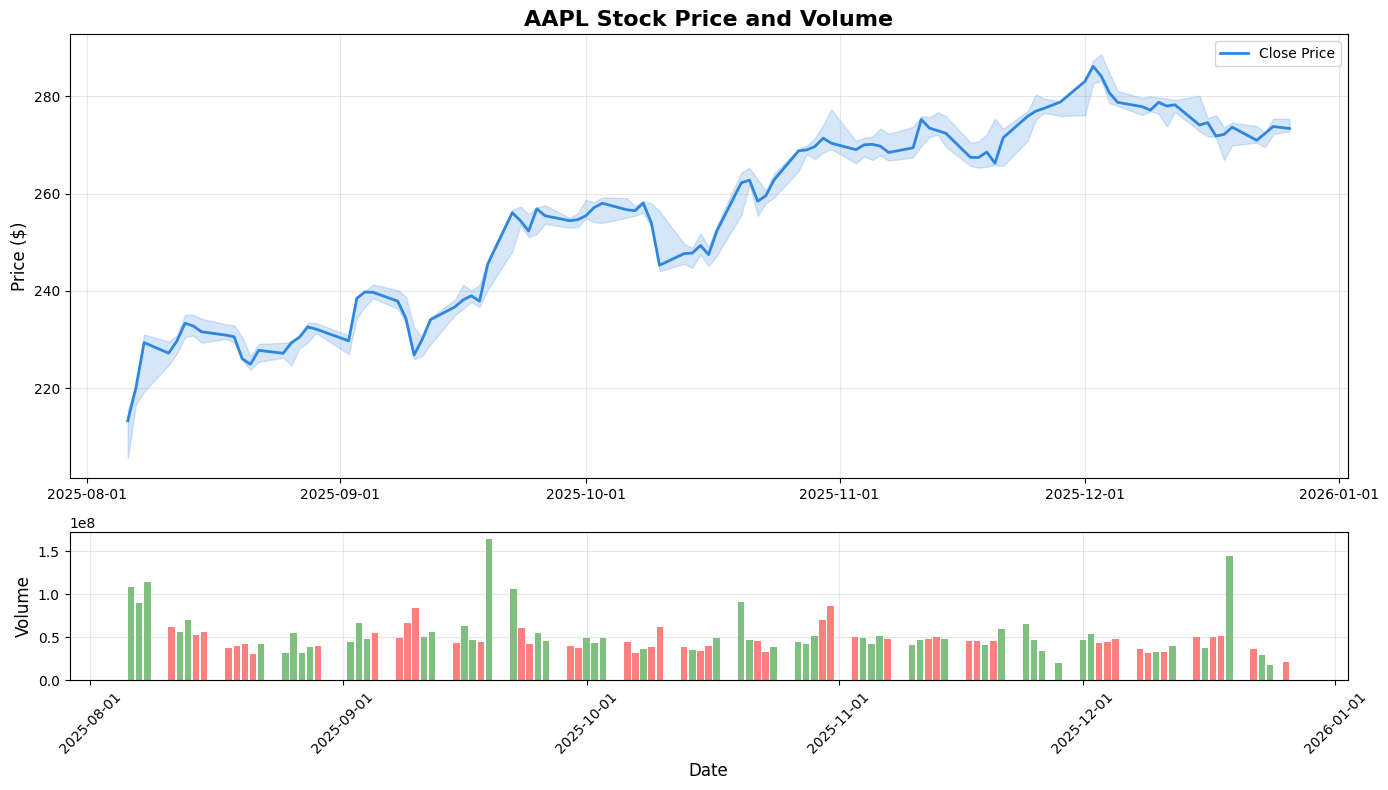

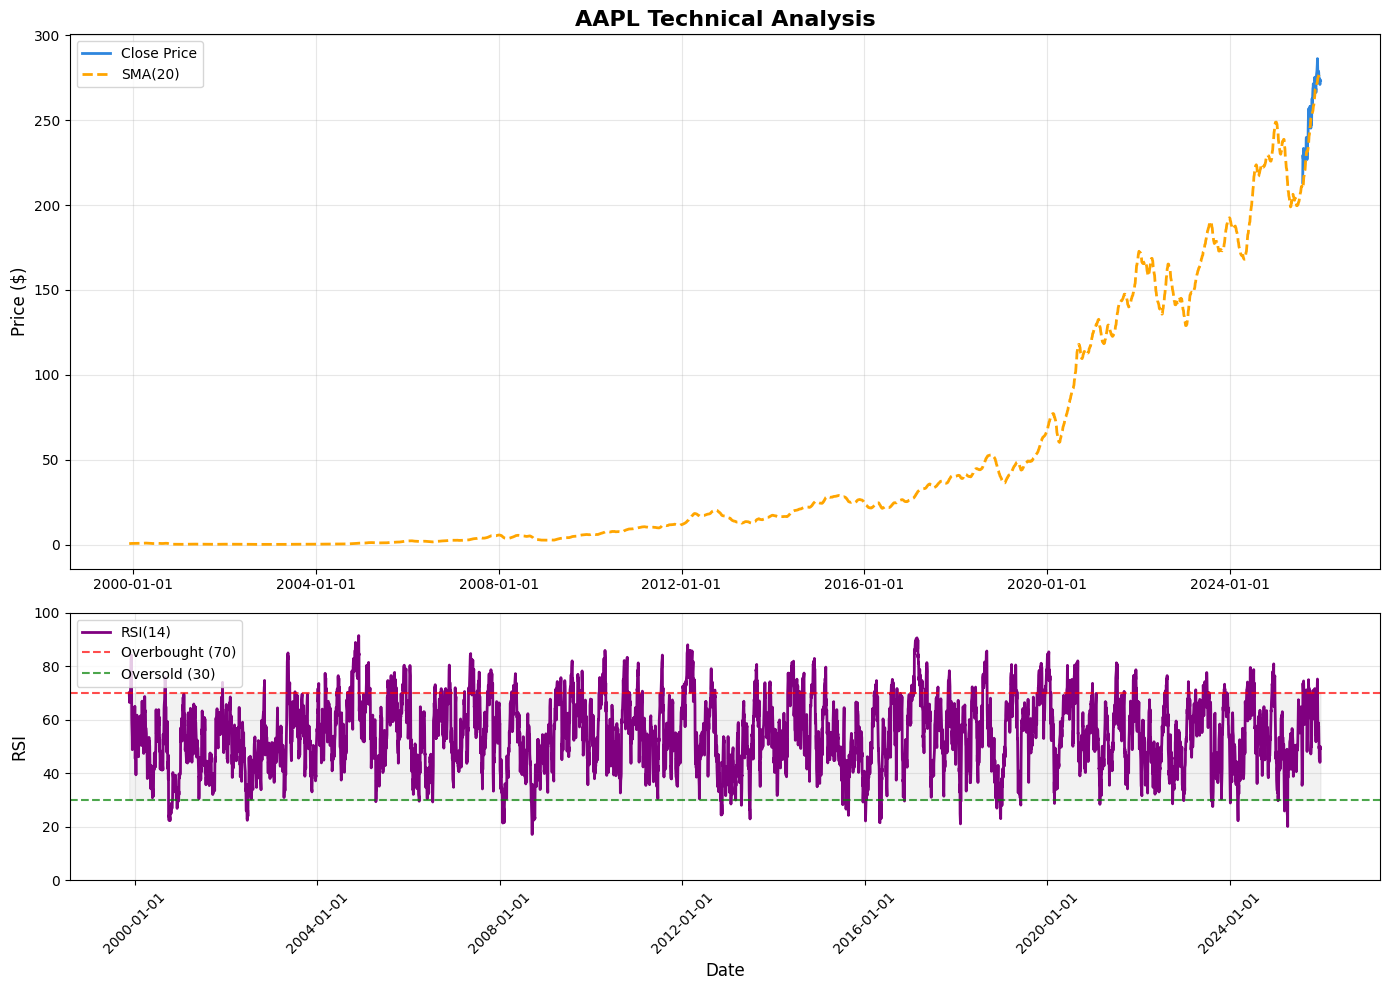

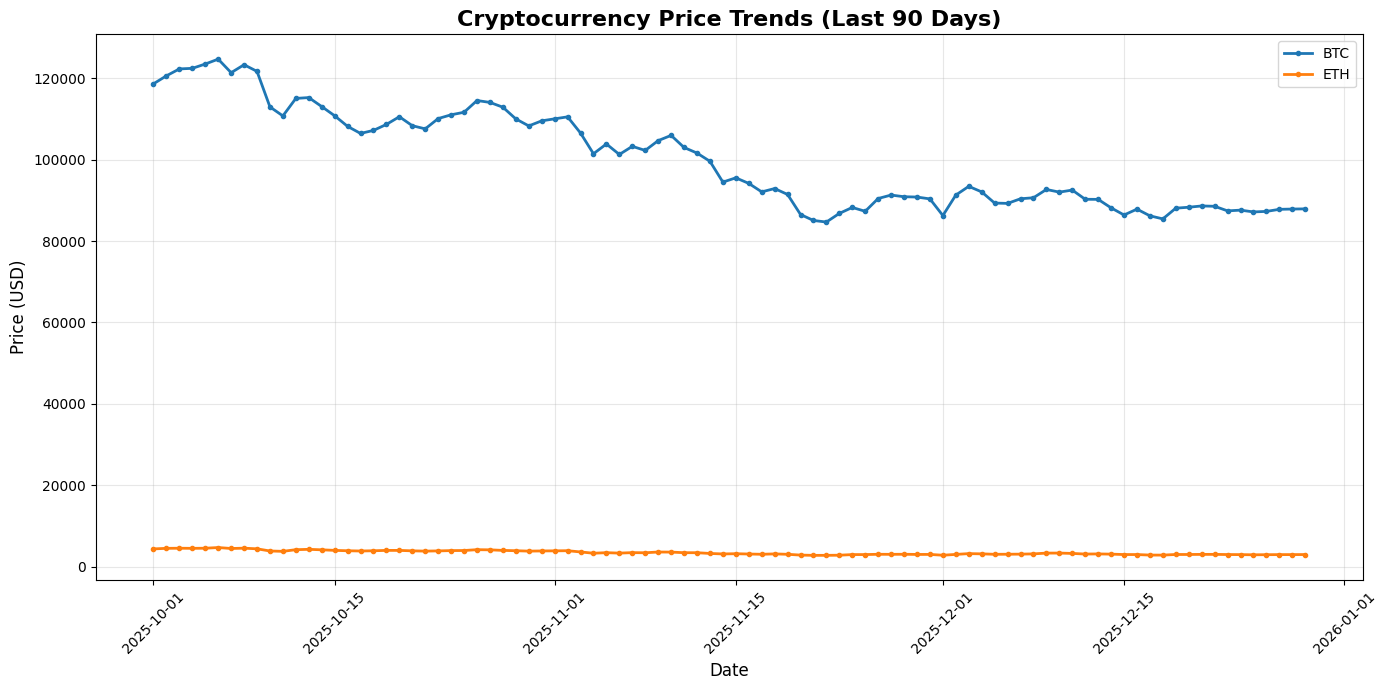

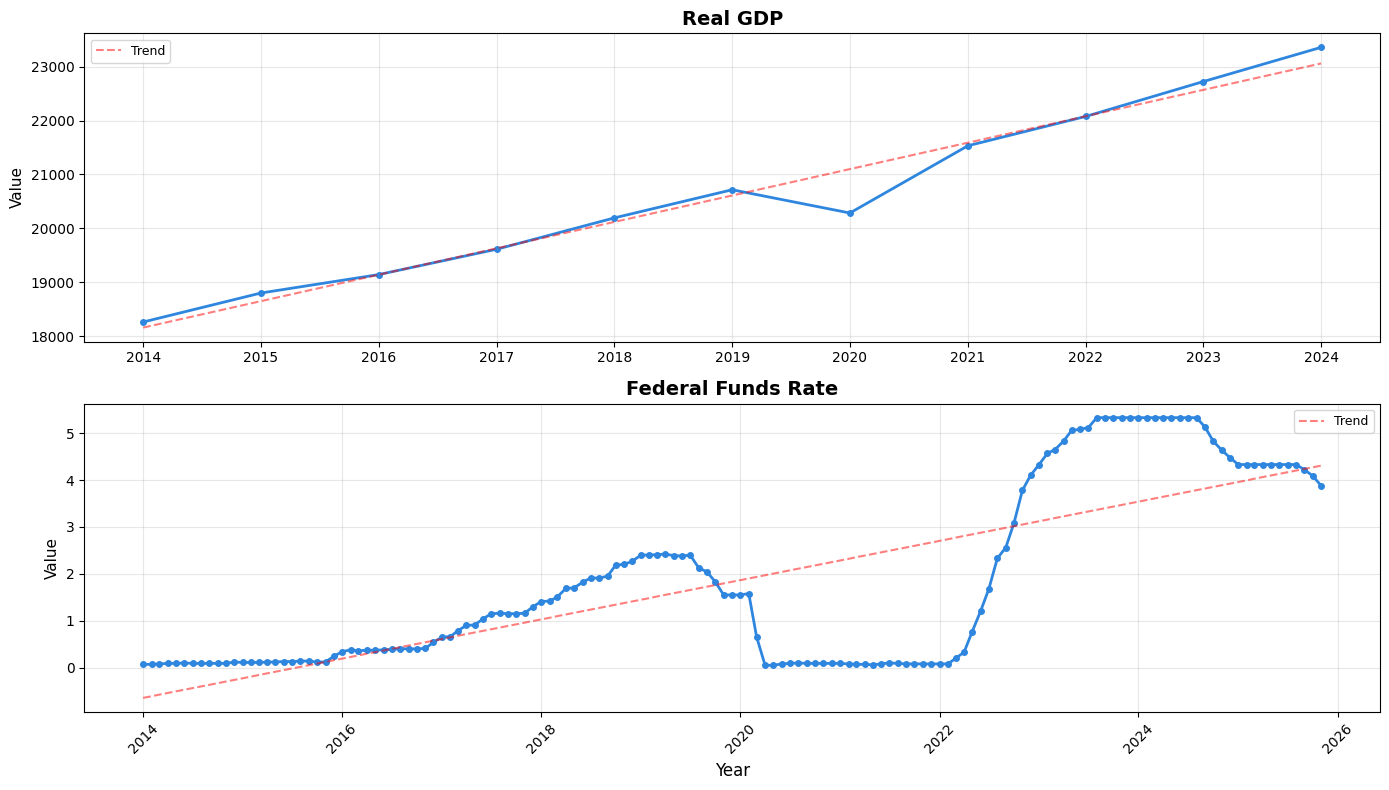

In [11]:


# =============================================================================
# API FUNCTIONS
# =============================================================================

def get_stock_daily(symbol, outputsize='compact'):
    """
    Get daily stock data (OHLCV)
    outputsize: 'compact' (last 100 days) or 'full' (20+ years)
    """
    params = {
        'function': 'TIME_SERIES_DAILY',
        'symbol': symbol,
        'outputsize': outputsize,
        'apikey': API_KEY
    }
    
    response = requests.get(BASE_URL, params=params)
    data = response.json()
    
    if 'Time Series (Daily)' in data:
        df = pd.DataFrame.from_dict(data['Time Series (Daily)'], orient='index')
        df.index = pd.to_datetime(df.index)
        df = df.astype(float)
        df.columns = ['open', 'high', 'low', 'close', 'volume']
        df = df.sort_index()
        return df
    else:
        print(f"Error fetching {symbol}: {data}")
        return None


def get_crypto_daily(symbol, market='USD'):
    """Get daily crypto data"""
    params = {
        'function': 'DIGITAL_CURRENCY_DAILY',
        'symbol': symbol,
        'market': market,
        'apikey': API_KEY
    }
    
    response = requests.get(BASE_URL, params=params)
    data = response.json()
    
    if 'Time Series (Digital Currency Daily)' in data:
        df = pd.DataFrame.from_dict(data['Time Series (Digital Currency Daily)'], orient='index')
        df.index = pd.to_datetime(df.index)
        
        # Handle different API response formats
        cols = df.columns.tolist()
        
        # Try to find the right column names (API format has changed over time)
        def find_col(patterns):
            for pattern in patterns:
                for col in cols:
                    if pattern in col.lower():
                        return col
            return None
        
        open_col = find_col(['1a. open', '1. open'])
        high_col = find_col(['2a. high', '2. high'])
        low_col = find_col(['3a. low', '3. low'])
        close_col = find_col(['4a. close', '4. close'])
        volume_col = find_col(['5. volume', 'volume'])
        
        if all([open_col, high_col, low_col, close_col, volume_col]):
            df['open'] = df[open_col].astype(float)
            df['high'] = df[high_col].astype(float)
            df['low'] = df[low_col].astype(float)
            df['close'] = df[close_col].astype(float)
            df['volume'] = df[volume_col].astype(float)
            
            df = df[['open', 'high', 'low', 'close', 'volume']]
            df = df.sort_index()
            return df
        else:
            print(f"Could not parse columns for {symbol}. Available: {cols}")
            return None
    else:
        print(f"Error fetching {symbol}: {data}")
        return None


def get_technical_indicator(symbol, function, interval='daily', time_period=14):
    """
    Get technical indicator (RSI, SMA, EMA, MACD, etc.)
    """
    params = {
        'function': function,
        'symbol': symbol,
        'interval': interval,
        'time_period': time_period,
        'series_type': 'close',
        'apikey': API_KEY
    }
    
    response = requests.get(BASE_URL, params=params)
    data = response.json()
    
    # Different indicators have different response keys
    for key in data.keys():
        if 'Technical Analysis' in key:
            df = pd.DataFrame.from_dict(data[key], orient='index')
            df.index = pd.to_datetime(df.index)
            df = df.astype(float)
            df = df.sort_index()
            return df
    
    print(f"Error fetching indicator: {data}")
    return None


def get_economic_indicator(function):
    """
    Get macroeconomic indicators
    Available: REAL_GDP, INFLATION, UNEMPLOYMENT, FEDERAL_FUNDS_RATE, etc.
    """
    params = {
        'function': function,
        'apikey': API_KEY
    }
    
    response = requests.get(BASE_URL, params=params)
    data = response.json()
    
    if 'data' in data:
        df = pd.DataFrame(data['data'])
        df['date'] = pd.to_datetime(df['date'])
        df['value'] = pd.to_numeric(df['value'], errors='coerce')
        df = df.dropna()
        df = df.sort_values('date')
        df = df.set_index('date')
        return df
    else:
        print(f"Error fetching {function}: {data}")
        return None


# =============================================================================
# VISUALIZATION FUNCTIONS
# =============================================================================

def plot_stock_comparison(stocks_data, title="Stock Price Comparison"):
    """Compare multiple stocks on normalized scale"""
    fig, ax = plt.subplots(figsize=(14, 7))
    
    for symbol, df in stocks_data.items():
        # Normalize to 100 at start
        normalized = (df['close'] / df['close'].iloc[0]) * 100
        ax.plot(normalized.index, normalized.values, label=symbol, linewidth=2)
    
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Normalized Price (Base = 100)', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    return fig


def plot_stock_with_volume(df, symbol, title=None):
    """Plot stock price with volume"""
    if title is None:
        title = f"{symbol} Stock Price and Volume"
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), 
                                     gridspec_kw={'height_ratios': [3, 1]})
    
    # Price chart
    ax1.plot(df.index, df['close'], color='#2E86DE', linewidth=2, label='Close Price')
    ax1.fill_between(df.index, df['low'], df['high'], alpha=0.2, color='#2E86DE')
    ax1.set_title(title, fontsize=16, fontweight='bold')
    ax1.set_ylabel('Price ($)', fontsize=12)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Volume chart
    colors = ['green' if df['close'].iloc[i] >= df['open'].iloc[i] else 'red' 
              for i in range(len(df))]
    ax2.bar(df.index, df['volume'], color=colors, alpha=0.5, width=0.8)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_ylabel('Volume', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    # Format dates
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    return fig


def plot_crypto_comparison(crypto_data, title="Cryptocurrency Comparison"):
    """Compare crypto prices"""
    fig, ax = plt.subplots(figsize=(14, 7))
    
    for symbol, df in crypto_data.items():
        # Get last 90 days for clarity
        df_recent = df.tail(90)
        ax.plot(df_recent.index, df_recent['close'], label=symbol, linewidth=2, marker='o', markersize=3)
    
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Price (USD)', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    return fig


def plot_technical_indicators(df, rsi_df, sma_df, symbol):
    """Plot price with RSI and SMA"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), 
                                     gridspec_kw={'height_ratios': [2, 1]})
    
    # Price and SMA
    ax1.plot(df.index, df['close'], label='Close Price', linewidth=2, color='#2E86DE')
    if sma_df is not None and not sma_df.empty:
        ax1.plot(sma_df.index, sma_df.iloc[:, 0], label='SMA(20)', 
                linewidth=2, color='orange', linestyle='--')
    ax1.set_title(f'{symbol} Technical Analysis', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Price ($)', fontsize=12)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # RSI
    if rsi_df is not None and not rsi_df.empty:
        ax2.plot(rsi_df.index, rsi_df.iloc[:, 0], label='RSI(14)', 
                linewidth=2, color='purple')
        ax2.axhline(y=70, color='red', linestyle='--', alpha=0.7, label='Overbought (70)')
        ax2.axhline(y=30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
        ax2.fill_between(rsi_df.index, 30, 70, alpha=0.1, color='gray')
    
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_ylabel('RSI', fontsize=12)
    ax2.set_ylim([0, 100])
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    # Format dates
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    return fig


def plot_economic_indicators(econ_data, title="US Economic Indicators"):
    """Plot multiple economic indicators"""
    num_indicators = len(econ_data)
    fig, axes = plt.subplots(num_indicators, 1, figsize=(14, 4*num_indicators))
    
    if num_indicators == 1:
        axes = [axes]
    
    for ax, (name, df) in zip(axes, econ_data.items()):
        # Get last 10 years
        df_recent = df[df.index >= '2014-01-01']
        
        ax.plot(df_recent.index, df_recent['value'], linewidth=2, 
               color='#2E86DE', marker='o', markersize=4)
        ax.set_title(name, fontsize=14, fontweight='bold')
        ax.set_ylabel('Value', fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        
        # Add trend line
        if len(df_recent) > 1:
            z = np.polyfit(range(len(df_recent)), df_recent['value'].values, 1)
            p = np.poly1d(z)
            ax.plot(df_recent.index, p(range(len(df_recent))), 
                   "--", alpha=0.5, color='red', label='Trend')
            ax.legend(fontsize=9)
    
    axes[-1].set_xlabel('Year', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    return fig


# =============================================================================
# MAIN ANALYSIS
# =============================================================================

def main():
    print("=" * 70)
    print("Alpha Vantage Trading Data Analysis")
    print("=" * 70)
    
    # Check API key
    if API_KEY == 'YOUR_API_KEY_HERE':
        print("\n⚠️  Please replace 'YOUR_API_KEY_HERE' with your actual API key!")
        print("Get your free API key at: https://www.alphavantage.co/support/#api-key")
        return
    
    # =============================================================================
    # 1. STOCK ANALYSIS
    # =============================================================================
    print("\n📊 Fetching Stock Data...")
    
    stock_symbols = ['AAPL', 'MSFT', 'GOOGL']
    stocks_data = {}
    
    for symbol in stock_symbols:
        print(f"  - Fetching {symbol}...")
        df = get_stock_daily(symbol, outputsize='compact')
        if df is not None:
            stocks_data[symbol] = df
            print(f"    ✓ Got {len(df)} days of data")
    
    if stocks_data:
        # Plot stock comparison
        fig1 = plot_stock_comparison(stocks_data, 
                                     "Tech Stocks Comparison (Normalized)")
        plt.savefig(OUTPUT_DIR / '1_stock_comparison.png', dpi=300, bbox_inches='tight')
        print(f"\n✓ Saved: {OUTPUT_DIR / '1_stock_comparison.png'}")
        
        # Detailed view of first stock with volume
        first_symbol = list(stocks_data.keys())[0]
        fig2 = plot_stock_with_volume(stocks_data[first_symbol], first_symbol)
        plt.savefig(OUTPUT_DIR / '2_stock_detail.png', dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {OUTPUT_DIR / '2_stock_detail.png'}")
    
    # =============================================================================
    # 2. TECHNICAL INDICATORS
    # =============================================================================
    print("\n📈 Fetching Technical Indicators...")
    
    if stocks_data:
        symbol = 'AAPL'
        print(f"  - RSI for {symbol}...")
        rsi_df = get_technical_indicator(symbol, 'RSI', time_period=14)
        
        print(f"  - SMA for {symbol}...")
        sma_df = get_technical_indicator(symbol, 'SMA', time_period=20)
        
        if rsi_df is not None or sma_df is not None:
            fig3 = plot_technical_indicators(stocks_data[symbol], rsi_df, sma_df, symbol)
            plt.savefig(OUTPUT_DIR / '3_technical_indicators.png', dpi=300, bbox_inches='tight')
            print(f"✓ Saved: {OUTPUT_DIR / '3_technical_indicators.png'}")
    
    # =============================================================================
    # 3. CRYPTOCURRENCY ANALYSIS
    # =============================================================================
    print("\n₿ Fetching Cryptocurrency Data...")
    
    crypto_symbols = ['BTC', 'ETH']
    crypto_data = {}
    
    for symbol in crypto_symbols:
        print(f"  - Fetching {symbol}...")
        df = get_crypto_daily(symbol)
        if df is not None:
            crypto_data[symbol] = df
            print(f"    ✓ Got {len(df)} days of data")
    
    if crypto_data:
        fig4 = plot_crypto_comparison(crypto_data, 
                                      "Cryptocurrency Price Trends (Last 90 Days)")
        plt.savefig(OUTPUT_DIR / '4_crypto_comparison.png', dpi=300, bbox_inches='tight')
        print(f"\n✓ Saved: {OUTPUT_DIR / '4_crypto_comparison.png'}")
    
    # =============================================================================
    # 4. MACROECONOMIC INDICATORS
    # =============================================================================
    print("\n🌍 Fetching Macroeconomic Data...")
    
    economic_indicators = {
        'Real GDP': 'REAL_GDP',
        'Inflation Rate (CPI)': 'INFLATION',
        'Unemployment Rate': 'UNEMPLOYMENT',
        'Federal Funds Rate': 'FEDERAL_FUNDS_RATE'
    }
    
    econ_data = {}
    
    for name, function in economic_indicators.items():
        print(f"  - Fetching {name}...")
        df = get_economic_indicator(function)
        if df is not None:
            econ_data[name] = df
            print(f"    ✓ Got {len(df)} data points")
    
    if econ_data:
        fig5 = plot_economic_indicators(econ_data, "US Economic Indicators (Last 10 Years)")
        plt.savefig(OUTPUT_DIR / '5_economic_indicators.png', dpi=300, bbox_inches='tight')
        print(f"\n✓ Saved: {OUTPUT_DIR / '5_economic_indicators.png'}")
    
    # =============================================================================
    # SUMMARY STATISTICS
    # =============================================================================
    print("\n" + "=" * 70)
    print("SUMMARY STATISTICS")
    print("=" * 70)
    
    if stocks_data:
        print("\n📊 STOCKS (Last 30 days):")
        for symbol, df in stocks_data.items():
            recent = df.tail(30)
            change = ((recent['close'].iloc[-1] - recent['close'].iloc[0]) / 
                     recent['close'].iloc[0] * 100)
            print(f"  {symbol}:")
            print(f"    Current: ${recent['close'].iloc[-1]:.2f}")
            print(f"    30-day change: {change:+.2f}%")
            print(f"    30-day high: ${recent['high'].max():.2f}")
            print(f"    30-day low: ${recent['low'].min():.2f}")
    
    if crypto_data:
        print("\n₿ CRYPTOCURRENCIES (Last 30 days):")
        for symbol, df in crypto_data.items():
            recent = df.tail(30)
            change = ((recent['close'].iloc[-1] - recent['close'].iloc[0]) / 
                     recent['close'].iloc[0] * 100)
            print(f"  {symbol}:")
            print(f"    Current: ${recent['close'].iloc[-1]:,.2f}")
            print(f"    30-day change: {change:+.2f}%")
            print(f"    30-day high: ${recent['high'].max():,.2f}")
            print(f"    30-day low: ${recent['low'].min():,.2f}")
    
    if econ_data:
        print("\n🌍 ECONOMIC INDICATORS (Latest):")
        for name, df in econ_data.items():
            latest = df.iloc[-1]
            print(f"  {name}:")
            print(f"    Latest value: {latest['value']:.2f}")
            print(f"    As of: {latest.name.strftime('%Y-%m-%d')}")
    
    print("\n" + "=" * 70)
    print(f"Analysis complete! Check {OUTPUT_DIR} for visualizations.")
    print("=" * 70)


if __name__ == "__main__":
    main()